In [ ]:
import os
import polars as pl
from pathlib import Path

# Setup file paths
RAW_DIR = Path("../../backend/data/raw")
OUTPUT_PATH = Path("../../backend/data/processed/m5_master_features.parquet")

def run_memory_efficient_pipeline():
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    print("Starting Preprocessing Pipeline...")

    # Force Polars to keep categorical indexes perfectly synchronized across files
    with pl.StringCache():
        
        # ---------------------------------------------------------
        # 1. Load & Optimize Small Dimension Tables (In-Memory)
        # ---------------------------------------------------------
        print("Loading and downcasting dimension tables...")
        
        # Optimize Calendar: Clean 'd' column to match numerical day index
        calendar = pl.read_csv(RAW_DIR / "calendar.csv").select([
            pl.col("d").str.replace("d_", "").cast(pl.Int16),
            pl.col("wday").cast(pl.Int8),
            pl.col("month").cast(pl.Int8),
            pl.col("event_name_1").is_not_null().cast(pl.Int8).alias("has_event"),
            pl.col("snap_CA").cast(pl.Int8),
            pl.col("snap_TX").cast(pl.Int8),
            pl.col("snap_WI").cast(pl.Int8),
            pl.col("wm_yr_wk").cast(pl.Int32)
        ])

        # Optimize Prices: Convert high-cardinality strings to Categoricals immediately
        prices = pl.read_csv(RAW_DIR / "sell_prices.csv").with_columns([
            pl.col("store_id").cast(pl.Categorical),
            pl.col("item_id").cast(pl.Categorical),
            pl.col("wm_yr_wk").cast(pl.Int32),
            pl.col("sell_price").cast(pl.Float32)
        ])

        # ---------------------------------------------------------
        # 2. Process Big Sales File via Lazy Store-by-Store Loop
        # ---------------------------------------------------------
        sales_lazy = pl.scan_csv(RAW_DIR / "sales_train_evaluation.csv")
        
        # Extract unique stores directly from data or define them
        stores = ["CA_1", "CA_2", "CA_3", "CA_4", "TX_1", "TX_2", "TX_3", "WI_1", "WI_2", "WI_3"]
        temp_files = []

        for store in stores:
            print(f"Processing Store [{store}]...")
            
            # Filter prices lazily for this specific store to optimize the hash join
            store_prices = prices.lazy().filter(pl.col("store_id") == store)
            
            # Build the pipeline execution graph for this specific store chunk
            store_pipeline = (
                sales_lazy.filter(pl.col("store_id") == store)
                # Unpivot (melt) columns from wide to long
                .unpivot(
                    index=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"], 
                    variable_name="d", 
                    value_name="sales"
                )
                # Downcast base types immediately to preserve RAM
                .with_columns([
                    pl.col("d").str.replace("d_", "").cast(pl.Int16),
                    pl.col("sales").cast(pl.Int16),
                    *[pl.col(c).cast(pl.Categorical) for c in ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]]
                ])
                # Join dimension data
                .join(calendar.lazy(), on="d", how="left")
                .join(store_prices, on=["store_id", "item_id", "wm_yr_wk"], how="left")
                # CRITICAL: Sort sequentially before executing rolling windows
                .sort(["item_id", "d"]))
                # ---------------------------------------------------------
                # NEW: True Hierarchical Feature Engineering
                # ---------------------------------------------------------
                # 1. Collapse to daily department totals
            dept_summary = (
                store_pipeline.group_by(["dept_id", "d"])
                .agg(pl.col("sales").sum().cast(pl.Float32).alias("dept_daily_sales"))
                .sort(["dept_id", "d"])
                # 2. Calculate the rolling macro-features on the true daily timeline
                .with_columns([
                    pl.col("dept_daily_sales").shift(28).rolling_mean(28).over("dept_id").alias("dept_roll_mean_28"),
                    pl.col("dept_daily_sales").shift(28).rolling_mean(7).over("dept_id").alias("dept_roll_mean_7")
                ])
                .select(["dept_id", "d", "dept_roll_mean_28", "dept_roll_mean_7"])
            )
            
            # 3. Join the macro-features back to the main item-level pipeline
            store_pipeline = store_pipeline.join(dept_summary, on=["dept_id", "d"], how="left")
                
                # ---------------------------------------------------------
                # Main Item-Level Feature Engineering
                # ---------------------------------------------------------
            store_pipeline = store_pipeline.with_columns([
                    # Base Lags and Momentum Features
                pl.col("sales").shift(28).rolling_mean(7).over("item_id").alias("roll_mean_7"),
                pl.col("sales").shift(28).rolling_mean(28).over("item_id").alias("roll_mean_28"),
                pl.col("sales").shift(28).ewm_mean(span=7).over("item_id").alias("ema_7"),
                pl.col("sales").shift(28).ewm_mean(span=28).over("item_id").alias("ema_28"),
                pl.col("sales").shift(28).ewm_std(span=7).over("item_id").alias("ewm_std_7"),
                pl.col("sales").shift(28).ewm_std(span=28).over("item_id").alias("ewm_std_28"),
                pl.col("sales").shift(7).over("item_id").alias("lag_7"),
                pl.col("sales").shift(28).over("item_id").alias("lag_28"),
                
                # ---------------------------------------------------------
                # 2. Intermittent Demand (Sparsity & Zero Handlers)
                # ---------------------------------------------------------
                # Calculates the percentage of days in the prior 28-day window with exactly 0 sales
                (pl.col("sales") == 0).cast(pl.Float32).shift(28).rolling_mean(28).over("item_id").alias("sparsity_ratio_28"),
                

                # ---------------------------------------------------------
                # 4. Advanced Temporal & Event Awareness
                # ---------------------------------------------------------
                # In the M5 dataset, wday 1 is Saturday and wday 2 is Sunday
                pl.col("wday").is_in([1, 2]).cast(pl.Int8).alias("is_weekend"),
                
                # ---------------------------------------------------------
                # 5. Dynamic SNAP Alignment
                # ---------------------------------------------------------
                # Collapses state-specific SNAP columns into a single boolean based on the row's state_id
                pl.when(pl.col("state_id") == "CA").then(pl.col("snap_CA"))
                .when(pl.col("state_id") == "TX").then(pl.col("snap_TX"))
                .when(pl.col("state_id") == "WI").then(pl.col("snap_WI"))
                .otherwise(0).cast(pl.Int8).alias("snap_active"),

                # ---------------------------------------------------------
                # 6. Base Price Elasticity Features
                # ---------------------------------------------------------
                pl.col("sell_price").shift(28).over("item_id").alias("price_lag_28"),
                ((pl.col("sell_price") - pl.col("sell_price").mean().over("item_id")) 
                / (pl.col("sell_price").std().over("item_id") + 1e-5)).cast(pl.Float32).alias("price_zscore")
                
            ]).with_columns([
                # ---------------------------------------------------------
                # 7. Price Momentum (Dependent on Step 6)
                # ---------------------------------------------------------
                # Measures the immediate relative change in price compared to the 28-day historical lag
                ((pl.col("sell_price") - pl.col("price_lag_28")) / (pl.col("price_lag_28") + 1e-5)).cast(pl.Float32).alias("price_change_ratio")
                
            ]).filter(
                pl.col("roll_mean_28").is_not_null()

            )
            
            # Cache this isolated store chunk directly to disk as a temporary parquet
            temp_path = f"../../backend/data/processed/temp_store_{store}.parquet"
            store_pipeline.collect().write_parquet(temp_path)
            temp_files.append(temp_path)
            
        # ---------------------------------------------------------
        # 4. Out-of-Core Serialization & Combining Outputs
        # ---------------------------------------------------------
        print("\nStitching processed store chunks into master production Parquet...")
        
        # Use .sink_parquet() to stream the files directly into the final location without loading them back into memory
        pl.concat([pl.scan_parquet(f) for f in temp_files]).sink_parquet(OUTPUT_PATH)
        
        # Clean up disk space
        print("Cleaning up intermediate cache layers...")
        for f in temp_files: 
            os.remove(f)
            
        print(f"SUCCESS: Master feature-engineered dataset saved to -> {OUTPUT_PATH}")

if __name__ == "__main__":
    run_memory_efficient_pipeline()

Starting Preprocessing Pipeline...
Loading and downcasting dimension tables...
Processing Store [CA_1]...
Processing Store [CA_2]...
Processing Store [CA_3]...
Processing Store [CA_4]...
Processing Store [TX_1]...
Processing Store [TX_2]...
Processing Store [TX_3]...
Processing Store [WI_1]...
Processing Store [WI_2]...
Processing Store [WI_3]...

Stitching processed store chunks into master production Parquet...
Cleaning up intermediate cache layers...
SUCCESS: Master feature-engineered dataset saved to -> ..\..\backend\data\processed\m5_master_features.parquet


In [26]:
df = pl.read_parquet('../../backend/data/processed/m5_master_features.parquet')

print(df.columns)
df.tail()


['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'wday', 'month', 'has_event', 'snap_CA', 'snap_TX', 'snap_WI', 'wm_yr_wk', 'sell_price', 'dept_roll_mean_28', 'dept_roll_mean_7', 'roll_mean_7', 'roll_mean_28', 'ema_7', 'ema_28', 'ewm_std_7', 'ewm_std_28', 'lag_7', 'lag_28', 'sparsity_ratio_28', 'is_weekend', 'snap_active', 'price_lag_28', 'price_zscore', 'price_change_ratio']


id,item_id,dept_id,cat_id,store_id,state_id,d,sales,wday,month,has_event,snap_CA,snap_TX,snap_WI,wm_yr_wk,sell_price,dept_roll_mean_28,dept_roll_mean_7,roll_mean_7,roll_mean_28,ema_7,ema_28,ewm_std_7,ewm_std_28,lag_7,lag_28,sparsity_ratio_28,is_weekend,snap_active,price_lag_28,price_zscore,price_change_ratio
cat,cat,cat,cat,cat,cat,i16,i16,i8,i8,i8,i8,i8,i8,i32,f32,f32,f32,f64,f64,f64,f64,f64,f64,i16,i16,f32,i8,i8,f32,f32,f32
"""FOODS_3_823_WI_3_evaluation""","""FOODS_3_823""","""FOODS_3""","""FOODS""","""WI_3""","""WI""",1941,1,2,5,0,0,0,0,11617,2.98,2054.321533,1928.0,0.285714,0.214286,0.404891,0.276234,0.582041,0.599301,3,1,0.857143,1,0,2.98,1.060015,0.0
"""FOODS_3_824_WI_3_evaluation""","""FOODS_3_824""","""FOODS_3""","""FOODS""","""WI_3""","""WI""",1941,0,2,5,0,0,0,0,11617,2.48,2054.321533,1928.0,0.142857,0.321429,0.21178,0.232407,0.443397,0.468252,0,0,0.714286,1,0,2.48,-0.111629,0.0
"""FOODS_3_825_WI_3_evaluation""","""FOODS_3_825""","""FOODS_3""","""FOODS""","""WI_3""","""WI""",1941,2,2,5,0,0,0,0,11617,3.98,2054.321533,1928.0,0.571429,0.892857,0.467169,0.820281,0.749084,1.071898,1,0,0.5,1,0,3.98,-0.731331,0.0
"""FOODS_3_826_WI_3_evaluation""","""FOODS_3_826""","""FOODS_3""","""FOODS""","""WI_3""","""WI""",1941,0,2,5,0,0,0,0,11617,1.28,2054.321533,1928.0,1.142857,0.928571,1.54449,1.081626,1.366288,1.143486,1,3,0.428571,1,0,1.28,0.0,0.0
"""FOODS_3_827_WI_3_evaluation""","""FOODS_3_827""","""FOODS_3""","""FOODS""","""WI_3""","""WI""",1941,1,2,5,0,0,0,0,11617,1.0,2054.321533,1928.0,0.0,1.071429,0.017042,0.690457,0.22425,1.414169,0,0,0.607143,1,0,1.0,0.0,0.0


In [1]:
! pip install pyarrow  cffi


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import lightgbm as lgb
import numpy as np
import pyarrow.dataset as ds
import tqdm
import gc

# Define global variables for the M5 dataset timeline
END_TRAIN_DAY = 1913
FORECAST_HORIZON = 28
N_FOLDS = 3
# Update this at the top of your script
QUANTILES = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]

def get_cv_splits(n_folds, end_day, horizon):
    """Generates train/val day thresholds for time-series expanding window CV."""
    splits = []
    for fold in range(n_folds):
        val_end = end_day - (fold * horizon)
        val_start = val_end - horizon + 1
        train_end = val_start - 1
        splits.append({
            "fold": fold + 1,
            "train_end": train_end,
            "val_start": val_start,
            "val_end": val_end
        })
    return splits

def wspl_metric(preds, train_data, alpha):
    """Custom Pinball Loss for LightGBM evaluation."""
    labels = train_data.get_label()
    # Weights should be derived from the M5 scaling factor per item
    weights = train_data.get_weight() if train_data.get_weight() is not None else np.ones_like(labels)
    
    error = labels - preds
    pinball_loss = np.where(error >= 0, alpha * error, (alpha - 1) * error)
    weighted_scaled_pinball = np.mean(pinball_loss * weights)
    
    return f'wspl_q{alpha}', weighted_scaled_pinball, False

def train_lgbm_cv_arrow(parquet_path, target_store="CA_1"):
    print("Initializing PyArrow Dataset...")
    dataset = ds.dataset(parquet_path, format="parquet")
    
    exclude_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'wm_yr_wk']
    all_cols = dataset.schema.names
    features = [col for col in all_cols if col not in exclude_cols]
    categorical_features = ['wday', 'month', 'snap_active', 'is_weekend', 'has_event']
    
    columns_to_read = features + ['sales']
    print(f"Training on {len(features)} features.")
    
    splits = get_cv_splits(N_FOLDS, END_TRAIN_DAY, FORECAST_HORIZON)
    
    # Store models in a nested structure: fold -> quantile -> model
    models = {split['fold']: {} for split in splits}
    
    base_params = {
        'objective': 'quantile', # Changed to quantile
        'metric': 'None', # We will use the custom feval
        'learning_rate': 0.05,
        'num_leaves': 63,
        'min_data_in_leaf': 50,
        'bagging_fraction': 0.8,
        'bagging_freq': 1,
        'feature_fraction': 0.8,
        'n_estimators': 1500,
        'early_stopping_rounds': 50,
        'verbose': -1,
        'random_state': 42
    }

    for split in tqdm.tqdm(splits, desc="Cross-Validation Progress"):
        print(f"\n--- Starting Fold {split['fold']} ---")
        
        # Load train set
        print("Loading train set directly to Arrow...")
        train_filter = (
            (ds.field("d") <= split["train_end"]) & 
            (ds.field("store_id") == target_store) & 
            ds.field("sales").is_valid()
        )
        
        train_table = dataset.to_table(filter=train_filter, columns=columns_to_read)
        y_train = train_table.column("sales").to_numpy()
        X_train = train_table.drop(["sales"])
        
        train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features, free_raw_data=True)
        del X_train, train_table, y_train
        gc.collect()
        
        # Load validation set
        print("Loading validation set directly to Arrow...")
        val_filter = (
            (ds.field("d") >= split["val_start"]) & 
            (ds.field("d") <= split["val_end"]) & 
            (ds.field("store_id") == target_store)
        )
        
        val_table = dataset.to_table(filter=val_filter, columns=columns_to_read)
        y_val = val_table.column("sales").to_numpy()
        X_val = val_table.drop(["sales"])
        
        val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_features, reference=train_data, free_raw_data=True)
        del X_val, val_table, y_val
        gc.collect()
        
        # Train 3 models per fold (one for each quantile)
        for q in QUANTILES:
            print(f"\n--- Training Fold {split['fold']} for Quantile {q} ---")
            
            # Copy base params and set specific quantile
            q_params = base_params.copy()
            q_params['alpha'] = q
            
            model = lgb.train(
                q_params,
                train_data,
                valid_sets=[train_data, val_data],
                valid_names=['train', 'valid'],
                callbacks=[
                    lgb.log_evaluation(period=50),
                    lgb.early_stopping(stopping_rounds=15),
                ],
                feval=lambda preds, train_data: wspl_metric(preds, train_data, q)
            )
            
            models[split['fold']][q] = model
            
    return models, features

trained_models_dict, model_features = train_lgbm_cv_arrow('../../backend/data/processed/m5_master_features.parquet')

Initializing PyArrow Dataset...
Training on 23 features.


Cross-Validation Progress:   0%|          | 0/3 [00:00<?, ?it/s]


--- Starting Fold 1 ---
Loading train set directly to Arrow...
Loading validation set directly to Arrow...

--- Training Fold 1 for Quantile 0.05 ---
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[1]	train's wspl_q0.05: 0.0662804	valid's wspl_q0.05: 0.0749397

--- Training Fold 1 for Quantile 0.1 ---
Training until validation scores don't improve for 15 rounds
[50]	train's wspl_q0.1: 0.129422	valid's wspl_q0.1: 0.144906
[100]	train's wspl_q0.1: 0.128618	valid's wspl_q0.1: 0.143793
Early stopping, best iteration is:
[95]	train's wspl_q0.1: 0.128618	valid's wspl_q0.1: 0.143793

--- Training Fold 1 for Quantile 0.25 ---
Training until validation scores don't improve for 15 rounds
[50]	train's wspl_q0.25: 0.288919	valid's wspl_q0.25: 0.32219
[100]	train's wspl_q0.25: 0.282981	valid's wspl_q0.25: 0.316542
[150]	train's wspl_q0.25: 0.282646	valid's wspl_q0.25: 0.316268
[200]	train's wspl_q0.25: 0.282603	valid's wspl_q0.25: 0.316224
[250]	tra

Cross-Validation Progress:  33%|███▎      | 1/3 [16:41<33:23, 1001.94s/it]

Early stopping, best iteration is:
[186]	train's wspl_q0.95: 0.189913	valid's wspl_q0.95: 0.215858

--- Starting Fold 2 ---
Loading train set directly to Arrow...
Loading validation set directly to Arrow...

--- Training Fold 2 for Quantile 0.05 ---
Training until validation scores don't improve for 15 rounds
Early stopping, best iteration is:
[16]	train's wspl_q0.05: 0.066167	valid's wspl_q0.05: 0.0732888

--- Training Fold 2 for Quantile 0.1 ---
Training until validation scores don't improve for 15 rounds
[50]	train's wspl_q0.1: 0.129301	valid's wspl_q0.1: 0.141905
[100]	train's wspl_q0.1: 0.12905	valid's wspl_q0.1: 0.141634
[150]	train's wspl_q0.1: 0.128788	valid's wspl_q0.1: 0.141235
[200]	train's wspl_q0.1: 0.128787	valid's wspl_q0.1: 0.141234
[250]	train's wspl_q0.1: 0.128755	valid's wspl_q0.1: 0.141163
[300]	train's wspl_q0.1: 0.128751	valid's wspl_q0.1: 0.141161
Early stopping, best iteration is:
[303]	train's wspl_q0.1: 0.128751	valid's wspl_q0.1: 0.141161

--- Training Fold 2

Cross-Validation Progress:  67%|██████▋   | 2/3 [31:10<15:23, 923.38s/it] 

Early stopping, best iteration is:
[167]	train's wspl_q0.95: 0.189872	valid's wspl_q0.95: 0.211235

--- Starting Fold 3 ---
Loading train set directly to Arrow...
Loading validation set directly to Arrow...

--- Training Fold 3 for Quantile 0.05 ---
Training until validation scores don't improve for 15 rounds
[50]	train's wspl_q0.05: 0.0660558	valid's wspl_q0.05: 0.0717145
Early stopping, best iteration is:
[54]	train's wspl_q0.05: 0.0660557	valid's wspl_q0.05: 0.0716928

--- Training Fold 3 for Quantile 0.1 ---
Training until validation scores don't improve for 15 rounds
[50]	train's wspl_q0.1: 0.129051	valid's wspl_q0.1: 0.139139
[100]	train's wspl_q0.1: 0.128077	valid's wspl_q0.1: 0.137939
Early stopping, best iteration is:
[124]	train's wspl_q0.1: 0.128077	valid's wspl_q0.1: 0.137939

--- Training Fold 3 for Quantile 0.25 ---
Training until validation scores don't improve for 15 rounds
[50]	train's wspl_q0.25: 0.288724	valid's wspl_q0.25: 0.31196
[100]	train's wspl_q0.25: 0.282086	

Cross-Validation Progress: 100%|██████████| 3/3 [43:45<00:00, 875.04s/it]

Early stopping, best iteration is:
[339]	train's wspl_q0.95: 0.187791	valid's wspl_q0.95: 0.212271


C:\Users\Admin\AppData\Local\Temp\ipykernel_29272\3602238008.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Mean_Gain', y='Feature', palette='viridis')


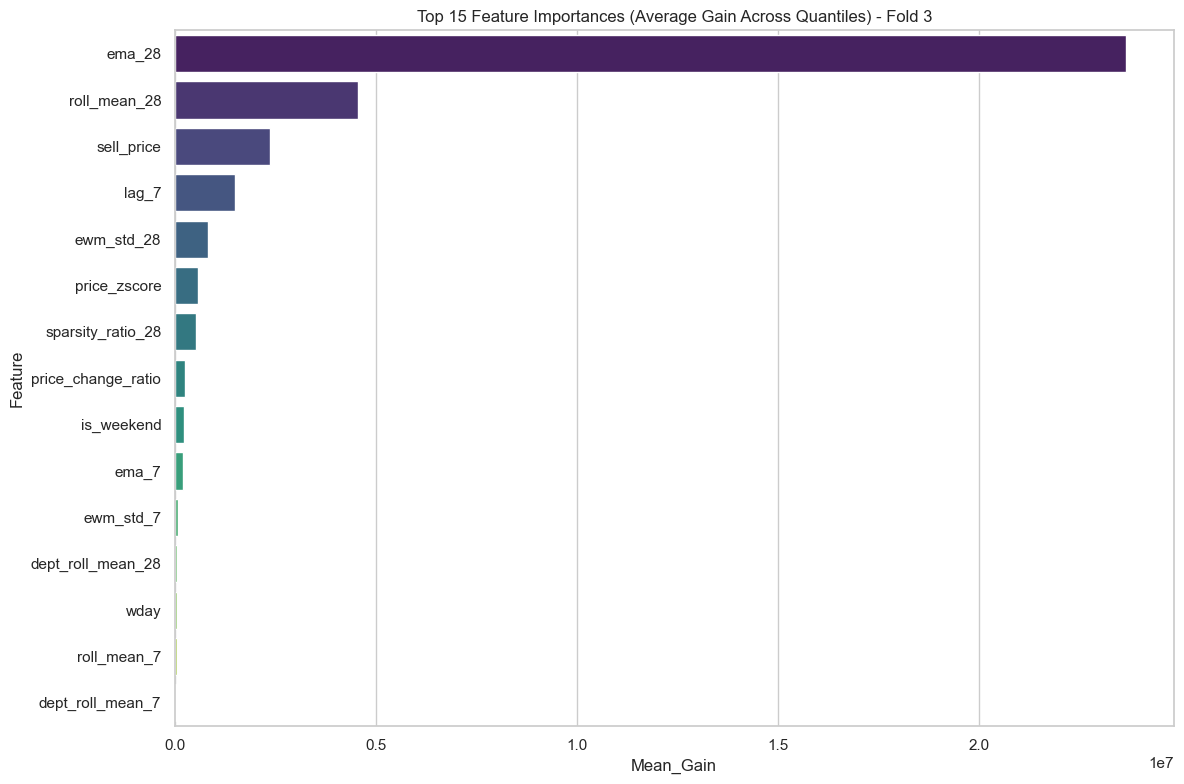

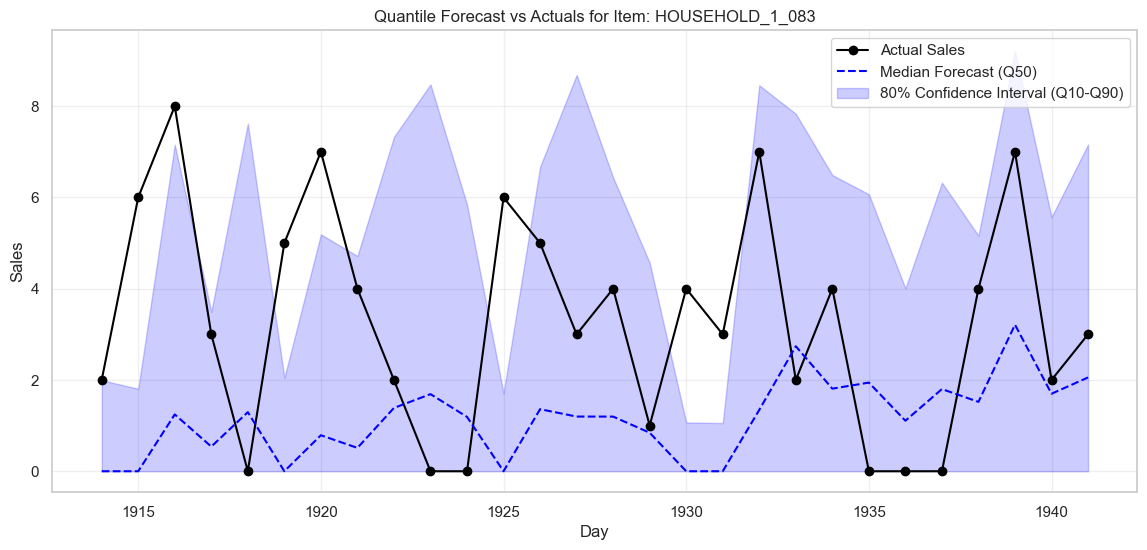

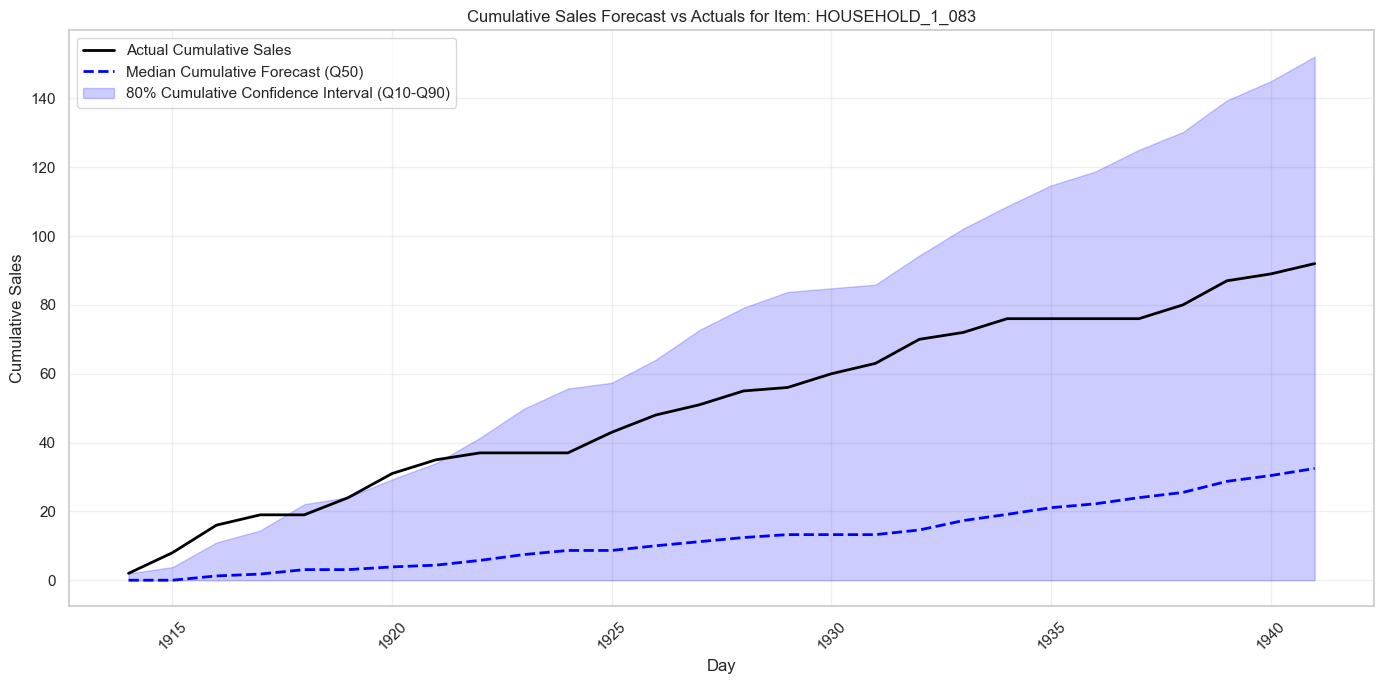

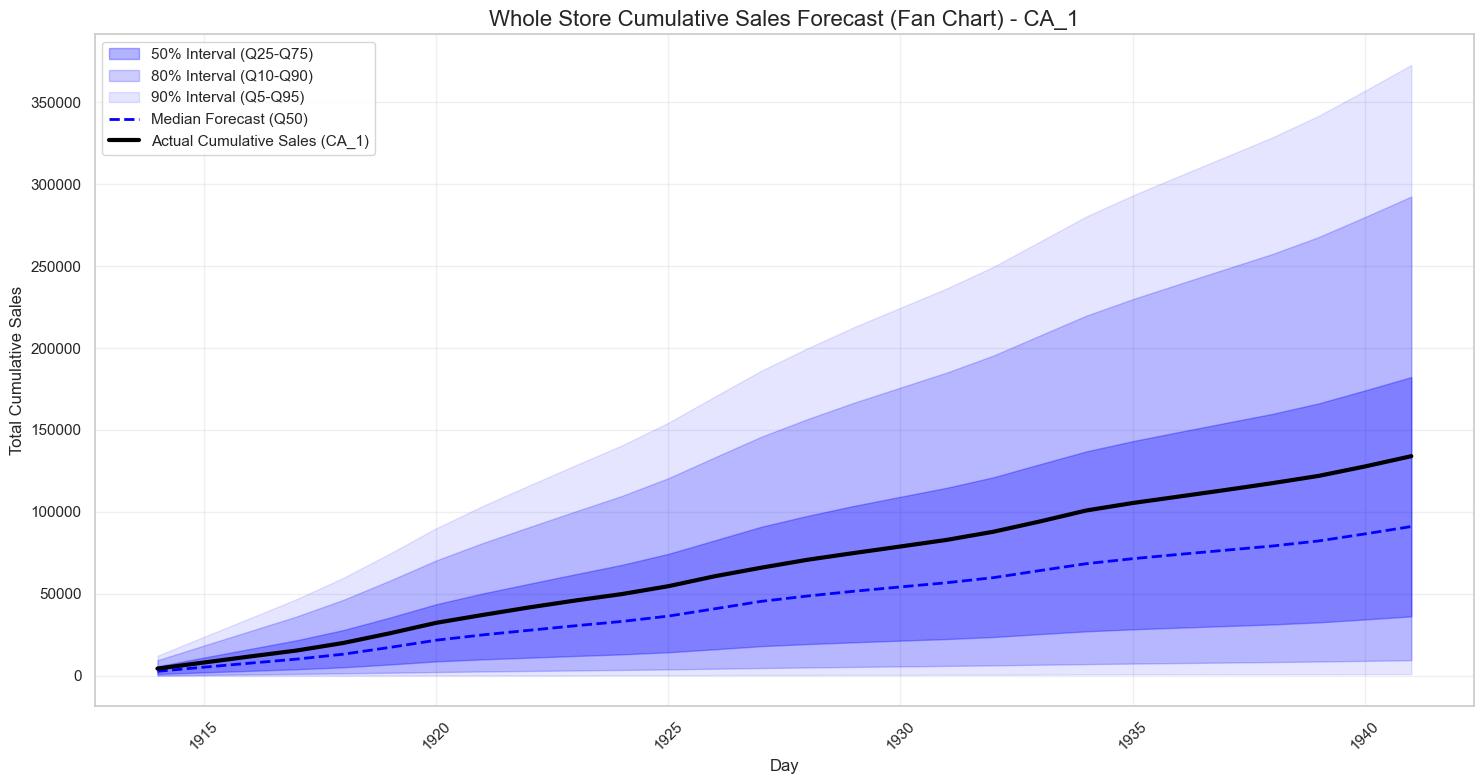

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_quantile_feature_importances(models_dict, fold, features):
    fold_models = models_dict[fold]
    
    # Extract importances for each quantile
    imp_10 = fold_models[0.1].feature_importance(importance_type='gain')
    imp_50 = fold_models[0.5].feature_importance(importance_type='gain')
    imp_90 = fold_models[0.9].feature_importance(importance_type='gain')
    
    # Create DataFrame
    importance_df = pd.DataFrame({
        'Feature': features,
        'Gain_Q10': imp_10,
        'Gain_Q50': imp_50,
        'Gain_Q90': imp_90
    })
    
    # Calculate Mean Gain across Quantiles
    importance_df['Mean_Gain'] = importance_df[['Gain_Q10', 'Gain_Q50', 'Gain_Q90']].mean(axis=1)
    importance_df = importance_df.sort_values(by='Mean_Gain', ascending=False).head(15)

    # Plot
    plt.figure(figsize=(12, 8))
    sns.barplot(data=importance_df, x='Mean_Gain', y='Feature', palette='viridis')
    plt.title(f"Top 15 Feature Importances (Average Gain Across Quantiles) - Fold {fold}")
    plt.tight_layout()
    plt.show()

# Extract the models from your last cross-validation run
final_fold = N_FOLDS
plot_quantile_feature_importances(trained_models_dict, final_fold, model_features)

def evaluate_quantile_forecast(parquet_path, models_dict, features, val_start, val_end, target_store, quantiles=QUANTILES):
    dataset = ds.dataset(parquet_path, format="parquet")
    
    val_filter = (
        (ds.field("d") >= val_start) & 
        (ds.field("d") <= val_end) & 
        (ds.field("store_id") == target_store)
    )
    
    columns_to_read = ['id', 'item_id', 'd', 'sales'] + features
    val_table = dataset.to_table(filter=val_filter, columns=columns_to_read)
    val_df = val_table.to_pandas()
    
    X_val = val_df[features]
    
    # Dynamically generate predictions for each quantile
    for q in quantiles:
        col_name = f'pred_q{int(q*100)}'
        val_df[col_name] = models_dict[q].predict(X_val)
        
    return val_df

val_start_day = 1914 
val_end_day = 1941   
# Run it
results_df = evaluate_quantile_forecast(
    parquet_path="../../backend/data/processed/m5_master_features.parquet",
    models_dict=trained_models_dict[final_fold],
    features=model_features,
    val_start=val_start_day,
    val_end=val_end_day,
    target_store="CA_1"
)


def plot_cumulative_sales_quantiles(results_df, item_id):
    """
    Plots the cumulative actual sales vs cumulative quantile forecasts for a specific item.
    """
    # Filter for the specific item and sort by day
    item_df = results_df[results_df['item_id'] == item_id].sort_values('d').copy()
    
    # Calculate cumulative sums
    item_df['cum_sales'] = item_df['sales'].cumsum()
    item_df['cum_pred_q10'] = item_df['pred_q10'].cumsum()
    item_df['cum_pred_q50'] = item_df['pred_q50'].cumsum()
    item_df['cum_pred_q90'] = item_df['pred_q90'].cumsum()
    
    # Plotting
    plt.figure(figsize=(14, 7))
    
    # Actual cumulative sales
    plt.plot(item_df['d'], item_df['cum_sales'], label='Actual Cumulative Sales', color='black', linewidth=2)
    
    # Median forecast cumulative sales
    plt.plot(item_df['d'], item_df['cum_pred_q50'], label='Median Cumulative Forecast (Q50)', color='blue', linestyle='--', linewidth=2)
    
    # 80% Confidence Interval
    plt.fill_between(
        item_df['d'], 
        item_df['cum_pred_q10'], 
        item_df['cum_pred_q90'], 
        color='blue', 
        alpha=0.2, 
        label='80% Cumulative Confidence Interval (Q10-Q90)'
    )
    
    plt.title(f"Cumulative Sales Forecast vs Actuals for Item: {item_id}")
    plt.xlabel("Day")
    plt.ylabel("Cumulative Sales")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # Format x-axis to avoid crowding if there are many days
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Function to plot the actuals vs P10, P50, and P90
def evaluate_single_item_quantiles(results_df, item_id):
    item_df = results_df[results_df['item_id'] == item_id].sort_values('d')
    
    plt.figure(figsize=(14, 6))
    plt.plot(item_df['d'], item_df['sales'], label='Actual Sales', color='black', marker='o')
    plt.plot(item_df['d'], item_df['pred_q50'], label='Median Forecast (Q50)', color='blue', linestyle='--')
    
    # Fill between Q10 and Q90 for the confidence interval
    plt.fill_between(item_df['d'], item_df['pred_q10'], item_df['pred_q90'], color='blue', alpha=0.2, label='80% Confidence Interval (Q10-Q90)')
    
    plt.title(f"Quantile Forecast vs Actuals for Item: {item_id}")
    plt.xlabel("Day")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plot_cumulative_sales_quantiles(results_df, item_id)

evaluate_single_item_quantiles(results_df, 'HOUSEHOLD_1_083')

def plot_store_cumulative_sales_fan(results_df, store_name="CA_1"):
    """
    Plots a layered 'fan chart' for store cumulative sales using 5%, 10%, 25%, 50%, 75%, 90%, 95% quantiles.
    """
    # Define the quantile columns we expect based on the new list
    q_cols = [f'pred_q{int(q*100)}' for q in [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]]
    
    # Aggregate sales and predictions by day
    daily_store_agg = results_df.groupby('d')[['sales'] + q_cols].sum().reset_index()
    daily_store_agg = daily_store_agg.sort_values('d')
    
    # Calculate the cumulative sums
    daily_store_agg['cum_sales'] = daily_store_agg['sales'].cumsum()
    for col in q_cols:
        daily_store_agg[f'cum_{col}'] = daily_store_agg[col].cumsum()
    
    # Plotting
    plt.figure(figsize=(15, 8))
    
    # Actual Sales
    plt.plot(daily_store_agg['d'], daily_store_agg['cum_sales'], 
             label=f'Actual Cumulative Sales ({store_name})', color='black', linewidth=3, zorder=5)
    
    # Median Forecast (Q50)
    plt.plot(daily_store_agg['d'], daily_store_agg['cum_pred_q50'], 
             label='Median Forecast (Q50)', color='blue', linestyle='--', linewidth=2, zorder=4)
    
    # Layer 1: 90% Interval (Q05 to Q95) - Lightest
    plt.fill_between(daily_store_agg['d'], daily_store_agg['cum_pred_q5'], daily_store_agg['cum_pred_q95'], 
                     color='blue', alpha=0.1, label='90% Interval (Q5-Q95)')
                     
    # Layer 2: 80% Interval (Q10 to Q90) - Medium
    plt.fill_between(daily_store_agg['d'], daily_store_agg['cum_pred_q10'], daily_store_agg['cum_pred_q90'], 
                     color='blue', alpha=0.2, label='80% Interval (Q10-Q90)')
                     
    # Layer 3: 50% Interval (Q25 to Q75) - Darkest
    plt.fill_between(daily_store_agg['d'], daily_store_agg['cum_pred_q25'], daily_store_agg['cum_pred_q75'], 
                     color='blue', alpha=0.3, label='50% Interval (Q25-Q75)')
    
    # Formatting
    plt.title(f"Whole Store Cumulative Sales Forecast (Fan Chart) - {store_name}", fontsize=16)
    plt.xlabel("Day", fontsize=12)
    plt.ylabel("Total Cumulative Sales", fontsize=12)
    
    # Reverse legend order so actuals are at the top
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles[::-1], labels[::-1], loc='upper left', fontsize=11)
    
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Run the fan chart
plot_store_cumulative_sales_fan(results_df, store_name="CA_1")



## Old ting


Loading evaluation data...
Generating predictions...

--- Global Metrics ---
Overall RMSE: 2.1947
Overall MAE:  1.1432


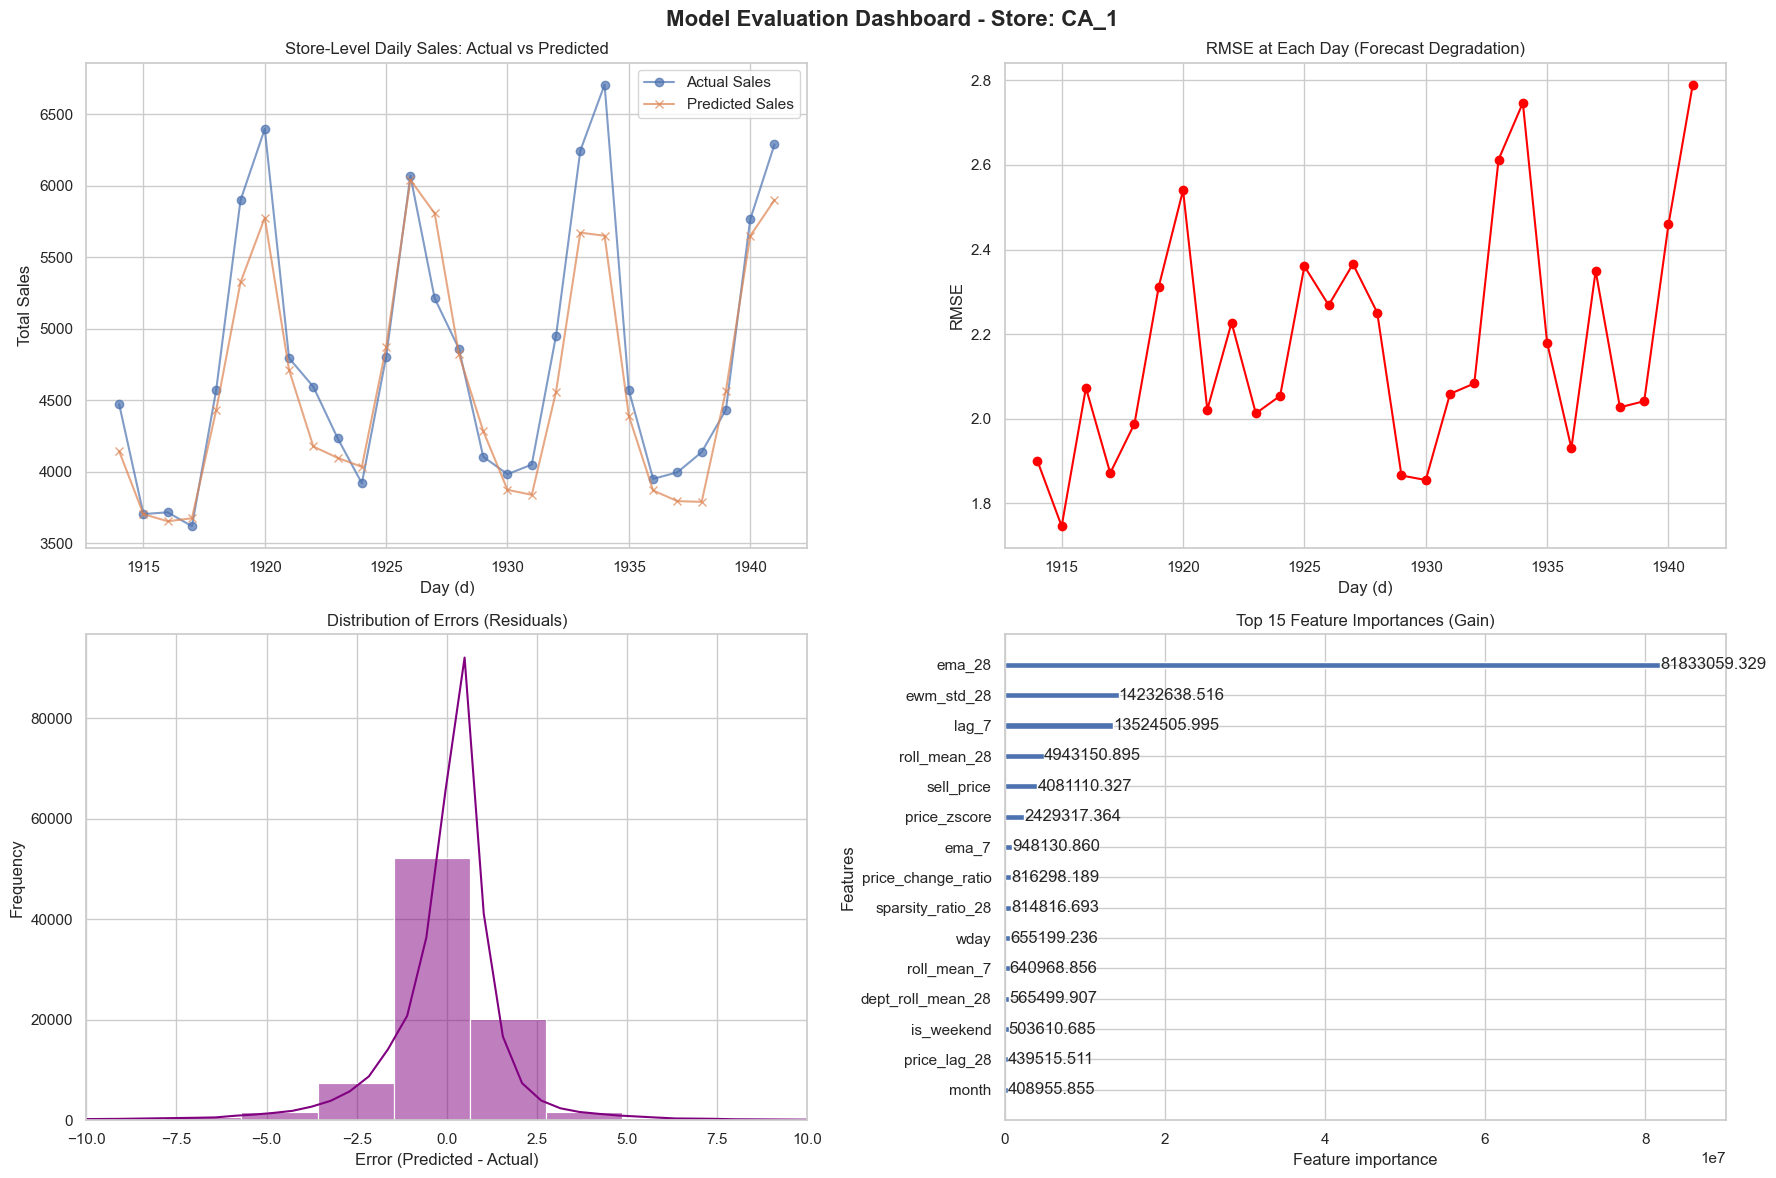

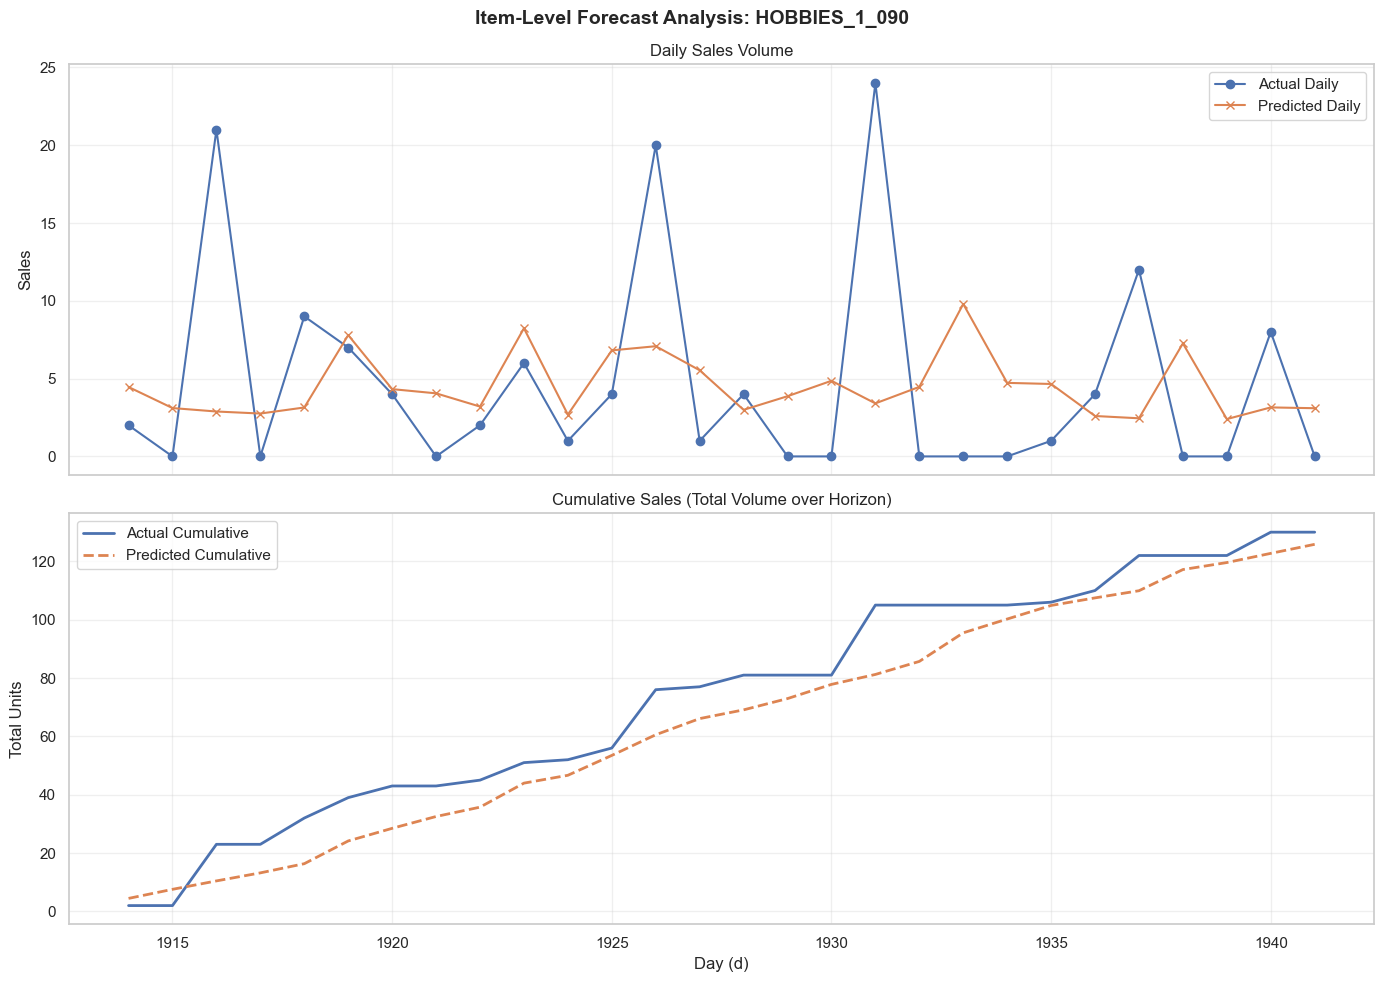

In [12]:
import pyarrow.dataset as ds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_single_item(val_df, item_id):
    """
    Plots the daily and cumulative Actual vs Predicted sales for a specific item.
    Requires the val_df returned from your main evaluation function.
    """
    # Filter for the specific item
    item_df = val_df[val_df['item_id'] == item_id].sort_values('d').copy()
    
    if item_df.empty:
        print(f"Item {item_id} not found in this validation set.")
        return
        
    # Calculate cumulative sums
    item_df['cum_sales'] = item_df['sales'].cumsum()
    item_df['cum_preds'] = item_df['predictions'].cumsum()
    
    # Create the plot
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"Item-Level Forecast Analysis: {item_id}", fontsize=14, fontweight='bold')
    
    # Plot 1: Daily Sales
    ax1 = axes[0]
    ax1.plot(item_df['d'], item_df['sales'], label='Actual Daily', marker='o')
    ax1.plot(item_df['d'], item_df['predictions'], label='Predicted Daily', marker='x')
    ax1.set_title("Daily Sales Volume")
    ax1.set_ylabel("Sales")
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Cumulative Sales
    ax2 = axes[1]
    ax2.plot(item_df['d'], item_df['cum_sales'], label='Actual Cumulative', linewidth=2)
    ax2.plot(item_df['d'], item_df['cum_preds'], label='Predicted Cumulative', linewidth=2, linestyle='--')
    ax2.set_title("Cumulative Sales (Total Volume over Horizon)")
    ax2.set_xlabel("Day (d)")
    ax2.set_ylabel("Total Units")
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Example usage (assuming 'results_df' is what your previous function returned):
# evaluate_single_item(results_df, 'HOBBIES_1_001')

def evaluate_lgbm_forecast(parquet_path, model, features, val_start, val_end, target_store="CA_1"):
    print("Loading evaluation data...")
    sns.set_theme(style="whitegrid")
    
    # 1. Load the Validation Data
    dataset = ds.dataset(parquet_path, format="parquet")
    # NEW CODE
    columns_to_read = features + ['sales', 'd', 'item_id']
    
    val_filter = (
        (ds.field("d") >= val_start) & 
        (ds.field("d") <= val_end) & 
        (ds.field("store_id") == target_store)
    )
    
    # Convert directly to Pandas for easier plotting and grouping
    val_df = dataset.to_table(filter=val_filter, columns=columns_to_read).to_pandas()
    
    y_true = val_df['sales'].values
    X_val = val_df[features]
    
    # 2. Generate Predictions
    print("Generating predictions...")
    preds = model.predict(X_val)
    val_df['predictions'] = preds
    val_df['error'] = val_df['predictions'] - val_df['sales']
    val_df['sq_error'] = val_df['error'] ** 2
    
    # 3. Calculate Global Metrics
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    mae = mean_absolute_error(y_true, preds)
    print(f"\n--- Global Metrics ---")
    print(f"Overall RMSE: {rmse:.4f}")
    print(f"Overall MAE:  {mae:.4f}")
    
    # 4. Prepare Data for Daily Plots
    # Aggregate sales and predictions by day to see the store-level trend
    daily_agg = val_df.groupby('d').agg({
        'sales': 'sum',
        'predictions': 'sum',
        'sq_error': 'mean' # Mean squared error per day
    }).reset_index()
    daily_agg['daily_rmse'] = np.sqrt(daily_agg['sq_error'])
    daily_agg = daily_agg.sort_values('d')
    
    # 5. Create the Visualization Dashboard
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(f"Model Evaluation Dashboard - Store: {target_store}", fontsize=16, fontweight='bold')
    
    # Plot A: Actual vs Predicted Sales (Aggregated Daily)
    ax1 = axes[0, 0]
    ax1.plot(daily_agg['d'], daily_agg['sales'], label='Actual Sales', marker='o', alpha=0.7)
    ax1.plot(daily_agg['d'], daily_agg['predictions'], label='Predicted Sales', marker='x', alpha=0.7)
    ax1.set_title("Store-Level Daily Sales: Actual vs Predicted")
    ax1.set_xlabel("Day (d)")
    ax1.set_ylabel("Total Sales")
    ax1.legend()
    
    # Plot B: Daily RMSE over the forecast horizon
    ax2 = axes[0, 1]
    ax2.plot(daily_agg['d'], daily_agg['daily_rmse'], color='red', marker='o')
    ax2.set_title("RMSE at Each Day (Forecast Degradation)")
    ax2.set_xlabel("Day (d)")
    ax2.set_ylabel("RMSE")
    
    # Plot C: Error Distribution (Residuals)
    ax3 = axes[1, 0]
    sns.histplot(val_df['error'], bins=50, kde=True, ax=ax3, color='purple')
    ax3.set_title("Distribution of Errors (Residuals)")
    ax3.set_xlabel("Error (Predicted - Actual)")
    ax3.set_ylabel("Frequency")
    ax3.set_xlim(-10, 10) # Adjust limits based on your data scale
    
    # Plot D: Feature Importance (Top 15)
    ax4 = axes[1, 1]
    lgb.plot_importance(model, max_num_features=15, ax=ax4, importance_type='gain', 
                        title="Top 15 Feature Importances (Gain)")
    
    plt.tight_layout()
    plt.show()
    
    return val_df

# Extract the last model from your cross-validation run
final_model = trained_models[-1] 

# Define the exact days that this specific model was validated on
val_start_day = 1914 
val_end_day = 1941   

# Run the evaluation
results_df = evaluate_lgbm_forecast(
    parquet_path="../../backend/data/processed/m5_master_features.parquet",
    model=final_model,
    features=model_features,
    val_start=val_start_day,
    val_end=val_end_day,
    target_store="CA_1"
)

evaluate_single_item(results_df, 'HOBBIES_1_090')